# Temporal Anlaysis of Message distribution

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# import datasets
df = pd.read_json("../../Datasets/voluntariosdanavalencia_old.json") # Import data from Voluntarios de Valencia groupchat.

## Distribution of messages (Close to the DANA in time)

In [4]:
# Check data structure
print(df.shape)
print(df.columns)
df.head()

(18064, 17)
Index(['id', 'date', 'message', 'reply_to_msg_id', 'views', 'forwards',
       'edit_date', 'pinned', 'post_author', 'sender_id', 'sender_username',
       'sender_name', 'has_media', 'reactions', 'subgroup', 'topic_name',
       'reply'],
      dtype='object')


,id,date,message,reply_to_msg_id,views,forwards,edit_date,pinned,post_author,sender_id,sender_username,sender_name,has_media,reactions,subgroup,topic_name,reply
0,3,2024-10-30 12:39:24+00:00,Os paso por aquí el correo,NaN,NaN,NaN,None,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,False,[],None,Discusión general,False
1,4,2024-10-30 12:40:50+00:00,LO AVISÉ EL VIERNES PASADO Y NADIE ME HIZO CAS...,NaN,46823.0,1057.0,2024-11-01T18:21:38+00:00,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,True,"[{'user_id': 5887977931, 'username': '', 'disp...",None,Discusión general,False
2,5,2024-10-30 12:43:17+00:00,,NaN,NaN,NaN,2024-11-03T22:44:05+00:00,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,True,"[{'user_id': 6970134793, 'username': '', 'disp...",None,Discusión general,False
3,6,2024-10-30 12:43:23+00:00,Probad si podeis,NaN,NaN,NaN,None,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,False,[],None,Discusión general,False
4,7,2024-10-30 12:46:02+00:00,Durante la tormenta al parecer sí estaba opera...,4.0,NaN,NaN,None,False,NaN,941865373,Camelocota,Víctor Conejero,False,[],Thread_4,Discusión general,True


In [5]:
# Convert date to datetime and sort by time
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Total messages: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

Total messages: 18064
Date range: 2024-10-30 12:39:24+00:00 to 2025-11-10 11:06:47+00:00


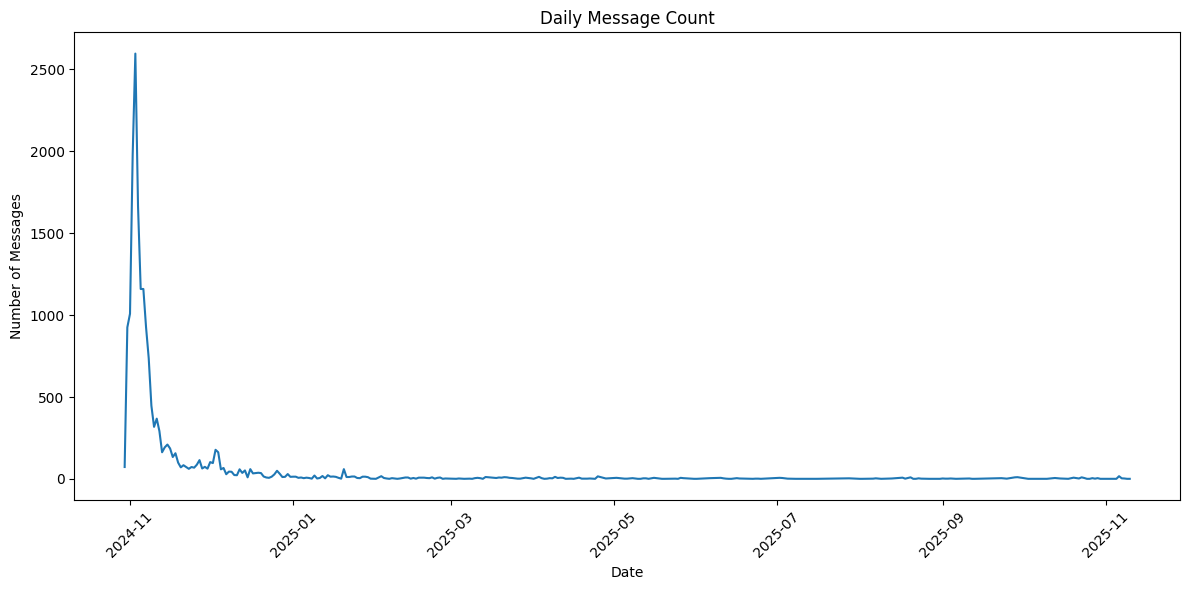

In [6]:
# Plot the distribution of messages over time (daily)
plt.figure(figsize=(12, 6))
df['date_only'] = df['date'].dt.date
daily_counts = df.groupby('date_only').size()
daily_counts.plot(kind='line')
plt.title('Daily Message Count')
plt.xlabel('Date')
plt.ylabel('Number of Messages')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

I talked with Emanuele and I could choose the cutoff using an exponential to see when it starts to decay exponentially. Talk to him to do so, right now I will just use January 1st as the cutoff.

### Distribution of messages until Jan 1st 2025

Total messages until Jan 1st 2025: 17044
Total messages sent in total (until Nov 10th 2025): 18064
Date range: 2024-10-30 12:39:24+00:00 to 2024-12-31 22:50:08+00:00


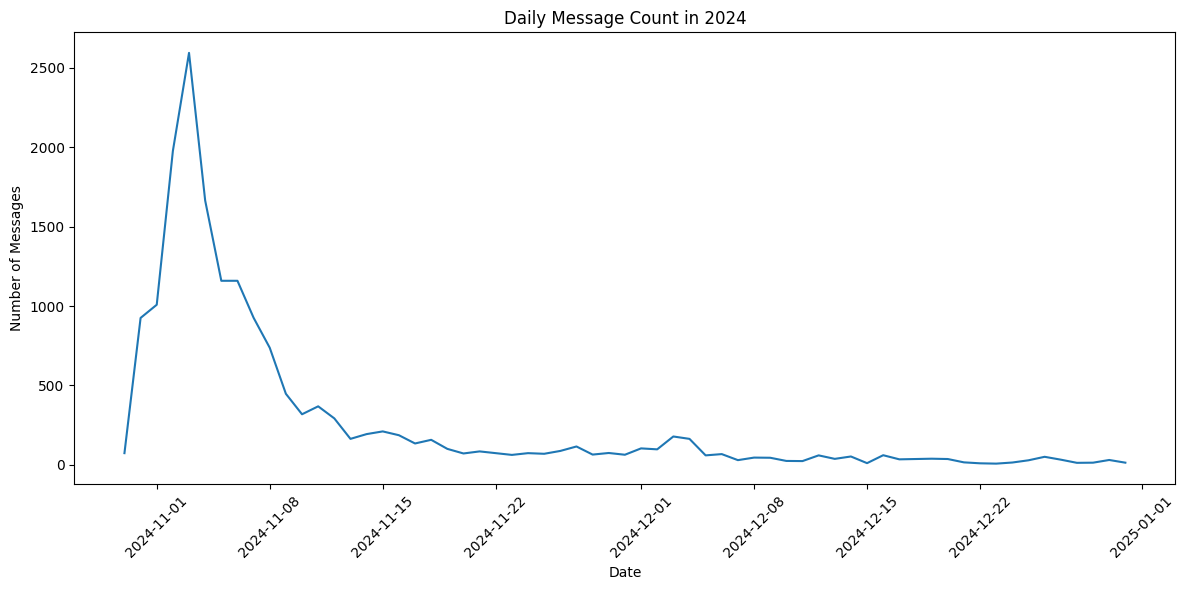

In [7]:
# Create new dataframe with messages until Jan 1st 2025
df_2024 = df[df['date'] < '2025-01-01'].copy()
print(f"Total messages until Jan 1st 2025: {len(df_2024)}")
print(f"Total messages sent in total (until Nov 10th 2025): {len(df)}")
print(f"Date range: {df_2024['date'].min()} to {df_2024['date'].max()}")

# Plot the distribution of messages over time (daily) for 2024
plt.figure(figsize=(12, 6))
df_2024['date_only'] = df_2024['date'].dt.date
daily_counts_2024 = df_2024.groupby('date_only').size()
daily_counts_2024.plot(kind='line', title='Daily Message Count in 2024')
plt.xlabel('Date')
plt.ylabel('Number of Messages')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

As it can be seen, the major part of the messages were sent in the first three months after the DANA.

In [8]:
# Calculate waiting times (inter-arrival times) between consecutive messages

# Calculate time differences in seconds
df_2024['waiting_time'] = df_2024['date'].diff().dt.total_seconds()

# Remove the first NaN value and negative values (if any)
waiting_times = df_2024['waiting_time'].dropna()
waiting_times = waiting_times[waiting_times > 0]

print(f"Number of waiting times: {len(waiting_times)}")
print(f"Statistics:")
print(f"  Mean: {waiting_times.mean():.2f} seconds ({waiting_times.mean()/60:.2f} minutes)")
print(f"  Median: {waiting_times.median():.2f} seconds ({waiting_times.median()/60:.2f} minutes)")
print(f"  Min: {waiting_times.min():.2f} seconds")
print(f"  Max: {waiting_times.max():.2f} seconds ({waiting_times.max()/3600:.2f} hours)")

Number of waiting times: 16222
Statistics:
  Mean: 332.48 seconds (5.54 minutes)
  Median: 35.00 seconds (0.58 minutes)
  Min: 1.00 seconds
  Max: 64566.00 seconds (17.93 hours)


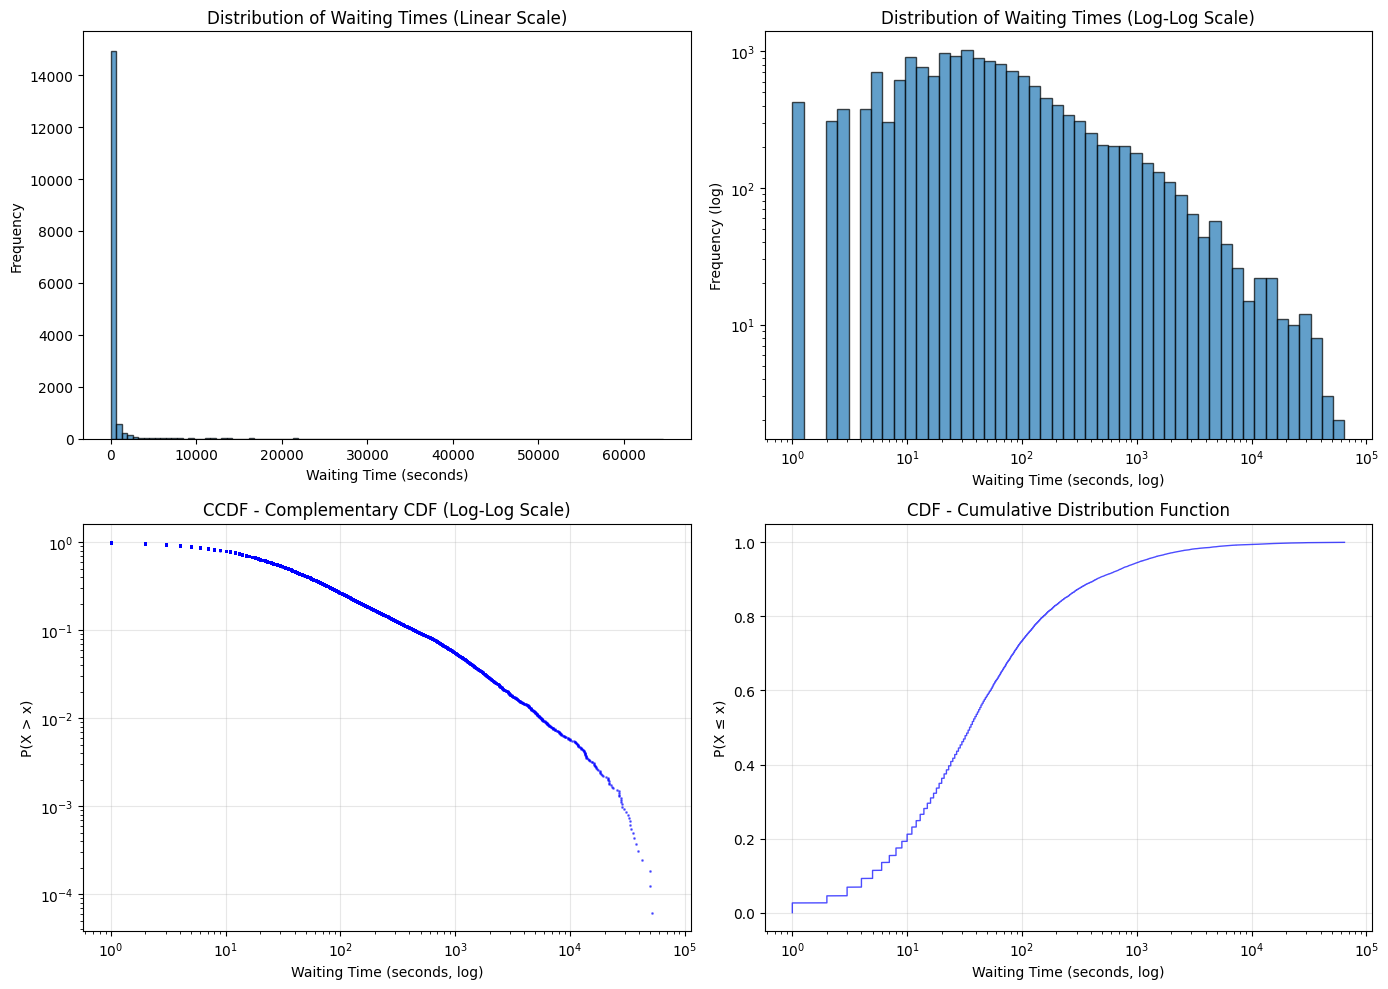

In [9]:
# Visualize the distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram on linear scale
axes[0, 0].hist(waiting_times, bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Waiting Time (seconds)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Waiting Times (Linear Scale)')

# Histogram on log-log scale
axes[0, 1].hist(waiting_times, bins=np.logspace(np.log10(waiting_times.min()), 
                                                  np.log10(waiting_times.max()), 50),
                edgecolor='black', alpha=0.7)
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')
axes[0, 1].set_xlabel('Waiting Time (seconds, log)')
axes[0, 1].set_ylabel('Frequency (log)')
axes[0, 1].set_title('Distribution of Waiting Times (Log-Log Scale)')

# CCDF (Complementary Cumulative Distribution Function) on log-log scale
sorted_times = np.sort(waiting_times)
ccdf = 1 - np.arange(1, len(sorted_times) + 1) / len(sorted_times)
axes[1, 0].plot(sorted_times, ccdf, 'b.', alpha=0.5, markersize=2)
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
axes[1, 0].set_xlabel('Waiting Time (seconds, log)')
axes[1, 0].set_ylabel('P(X > x)')
axes[1, 0].set_title('CCDF - Complementary CDF (Log-Log Scale)')
axes[1, 0].grid(True, alpha=0.3)

# CDF
axes[1, 1].plot(sorted_times, np.arange(1, len(sorted_times) + 1) / len(sorted_times), 
                'b-', alpha=0.7, linewidth=1)
axes[1, 1].set_xscale('log')
axes[1, 1].set_xlabel('Waiting Time (seconds, log)')
axes[1, 1].set_ylabel('P(X ≤ x)')
axes[1, 1].set_title('CDF - Cumulative Distribution Function')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Fit to truncated power law

TRUNCATED POWER LAW FIT RESULTS
alpha: 1.6055
lambda: 0.000038
xmin: 53.0000
sigma: nan
Data points above xmin: 6535 / 16222 (40.28%)

TRUNCATED POWER LAW COMPARISONS


Assuming nested distributions



Truncated PL vs Power Law:
  R = 9.4052, p = 0.0000
  ✓ Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 4.2500, p = 0.0000
  ✓ Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 22.9279, p = 0.0000
  ✓ Truncated power law is significantly better

KS distance (truncated power law): 0.0118
✓ Good fit (KS < 0.1)


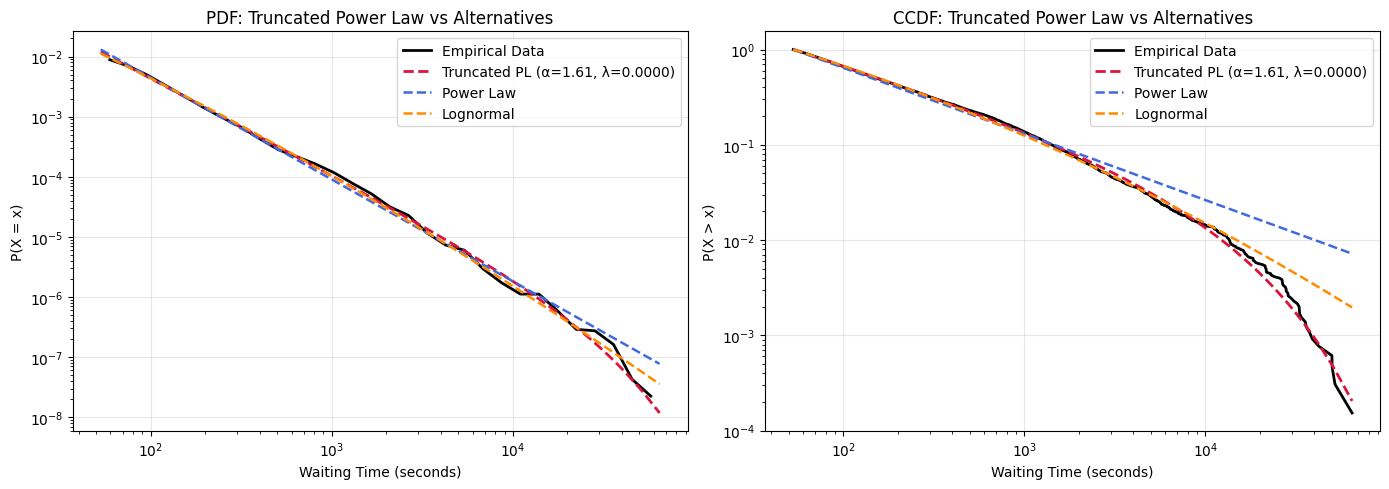

KS statistic (tail): 0.011910
KS p-value (tail): 0.309611


In [10]:
import powerlaw

# Prepare data
data_tpl = np.asarray(waiting_times.values, dtype=float)
data_tpl = data_tpl[np.isfinite(data_tpl)]
data_tpl = data_tpl[data_tpl > 0]

# Fit using powerlaw package
fit_tpl = powerlaw.Fit(data_tpl, discrete=False, verbose=False)
tpl = fit_tpl.truncated_power_law

alpha_tpl = getattr(tpl, "alpha", np.nan)
lambda_tpl = getattr(tpl, "Lambda", np.nan)
xmin_tpl = getattr(tpl, "xmin", np.nan)
sigma_tpl = getattr(tpl, "sigma", np.nan)

print("="*70)
print("TRUNCATED POWER LAW FIT RESULTS")
print("="*70)
print(f"alpha: {alpha_tpl:.4f}")
print(f"lambda: {lambda_tpl:.6f}")
print(f"xmin: {xmin_tpl:.4f}")
print(f"sigma: {sigma_tpl:.4f}")
n_tail_tpl = int(np.sum(data_tpl >= xmin_tpl))
print(f"Data points above xmin: {n_tail_tpl} / {len(data_tpl)} ({100 * n_tail_tpl / len(data_tpl):.2f}%)")

# Likelihood-ratio comparisons (positive R => first model preferred)
print("\n" + "="*70)
print("TRUNCATED POWER LAW COMPARISONS")
print("="*70)
comparisons = [
    ("truncated_power_law", "power_law", "Truncated PL vs Power Law"),
    ("truncated_power_law", "lognormal", "Truncated PL vs Lognormal"),
    ("truncated_power_law", "exponential", "Truncated PL vs Exponential"),
]

for d1, d2, label in comparisons:
    R, p = fit_tpl.distribution_compare(d1, d2, normalized_ratio=True)
    print(f"\n{label}:")
    print(f"  R = {R:.4f}, p = {p:.4f}")
    if p < 0.05:
        if R > 0:
            print("  ✓ Truncated power law is significantly better")
        else:
            print(f"  ✗ {d2.replace('_', ' ')} is significantly better")
    else:
        print("  ≈ No significant difference")

# Manual KS distance for truncated power law
tail_tpl = np.sort(data_tpl[data_tpl >= xmin_tpl])
if len(tail_tpl) == 0:
    ks_tpl = float("nan")
else:
    empirical_cdf_tpl = np.arange(1, len(tail_tpl) + 1) / len(tail_tpl)
    try:
        model_cdf_tpl = tpl.cdf(tail_tpl)
    except Exception:
        model_cdf_tpl = 1 - tpl.ccdf(tail_tpl)
    ks_tpl = np.max(np.abs(empirical_cdf_tpl - model_cdf_tpl))

print("\n" + "="*70)
print(f"KS distance (truncated power law): {ks_tpl:.4f}")
if np.isnan(ks_tpl):
    print("KS could not be computed (no data >= xmin).")
elif ks_tpl < 0.1:
    print("✓ Good fit (KS < 0.1)")
elif ks_tpl < 0.15:
    print("~ Moderate fit (0.1 ≤ KS < 0.15)")
else:
    print("✗ Poor fit (KS ≥ 0.15)")
print("="*70)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fit_tpl.plot_pdf(color='black', linewidth=2, label='Empirical Data', ax=axes[0])
tpl.plot_pdf(
    color='crimson', linestyle='--', linewidth=2,
    label=f'Truncated PL (α={alpha_tpl:.2f}, λ={lambda_tpl:.4f})', ax=axes[0]
 )
fit_tpl.power_law.plot_pdf(color='royalblue', linestyle='--', linewidth=1.8, label='Power Law', ax=axes[0])
fit_tpl.lognormal.plot_pdf(color='darkorange', linestyle='--', linewidth=1.8, label='Lognormal', ax=axes[0])
axes[0].set_xlabel('Waiting Time (seconds)')
axes[0].set_ylabel('P(X = x)')
axes[0].set_title('PDF: Truncated Power Law vs Alternatives')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

fit_tpl.plot_ccdf(color='black', linewidth=2, label='Empirical Data', ax=axes[1])
tpl.plot_ccdf(
    color='crimson', linestyle='--', linewidth=2,
    label=f'Truncated PL (α={alpha_tpl:.2f}, λ={lambda_tpl:.4f})', ax=axes[1]
 )
fit_tpl.power_law.plot_ccdf(color='royalblue', linestyle='--', linewidth=1.8, label='Power Law', ax=axes[1])
fit_tpl.lognormal.plot_ccdf(color='darkorange', linestyle='--', linewidth=1.8, label='Lognormal', ax=axes[1])
axes[1].set_xlabel('Waiting Time (seconds)')
axes[1].set_ylabel('P(X > x)')
axes[1].set_title('CCDF: Truncated Power Law vs Alternatives')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# One-off: compute KS p-value for truncated power law tail fit
from scipy import stats

tail_tpl = np.sort(data_tpl[data_tpl >= xmin_tpl])
ks_stat_tpl, ks_p_tpl = stats.kstest(tail_tpl, tpl.cdf)
print("="*70)
print(f"KS statistic (tail): {ks_stat_tpl:.6f}")
print(f"KS p-value (tail): {ks_p_tpl:.6g}")
print("="*70)

## Waiting times for the two weeks after the DANA

Here we will only consider messages until 2 weeks after the rain on Oct. 29th 2024 (Nov. 12 2024)

Total messages during first two weeks: 13649
Total messages sent in total (until Nov 10th 2025): 18064
Date range: 2024-10-30 12:39:24+00:00 to 2024-11-12 23:41:24+00:00


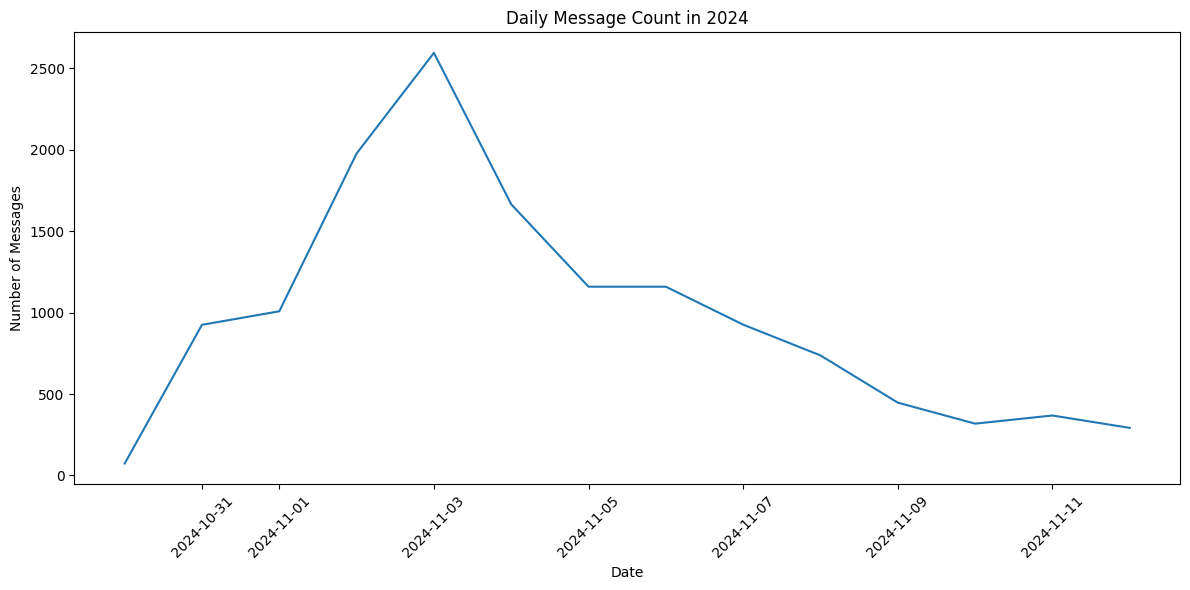

In [11]:
# Create new dataframe with messages during the first two weeks (until Nov. 12th 2024)
df_twoweeks = df[df['date'] < '2024-11-13'].copy()
print(f"Total messages during first two weeks: {len(df_twoweeks)}")
print(f"Total messages sent in total (until Nov 10th 2025): {len(df)}")
print(f"Date range: {df_twoweeks['date'].min()} to {df_twoweeks['date'].max()}")

# Plot the distribution of messages over time (daily) for 2024
plt.figure(figsize=(12, 6))
df_2024['date_only'] = df_twoweeks['date'].dt.date
daily_counts_2024 = df_2024.groupby('date_only').size()
daily_counts_2024.plot(kind='line', title='Daily Message Count in 2024')
plt.xlabel('Date')
plt.ylabel('Number of Messages')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# Calculate time differences in seconds
df_twoweeks['waiting_time'] = df_twoweeks['date'].diff().dt.total_seconds()

# Remove the first NaN value and negative values (if any)
waiting_times_w = df_twoweeks['waiting_time'].dropna()
waiting_times_w = waiting_times_w[waiting_times_w > 0]

print(f"Number of waiting times: {len(waiting_times_w)}")
print(f"Statistics:")
print(f"  Mean: {waiting_times_w.mean():.2f} seconds ({waiting_times_w.mean()/60:.2f} minutes)")
print(f"  Median: {waiting_times_w.median():.2f} seconds ({waiting_times_w.median()/60:.2f} minutes)")
print(f"  Min: {waiting_times_w.min():.2f} seconds")
print(f"  Max: {waiting_times_w.max():.2f} seconds ({waiting_times_w.max()/3600:.2f} hours)")

Number of waiting times: 12983
Statistics:
  Mean: 89.57 seconds (1.49 minutes)
  Median: 27.00 seconds (0.45 minutes)
  Min: 1.00 seconds
  Max: 26854.00 seconds (7.46 hours)


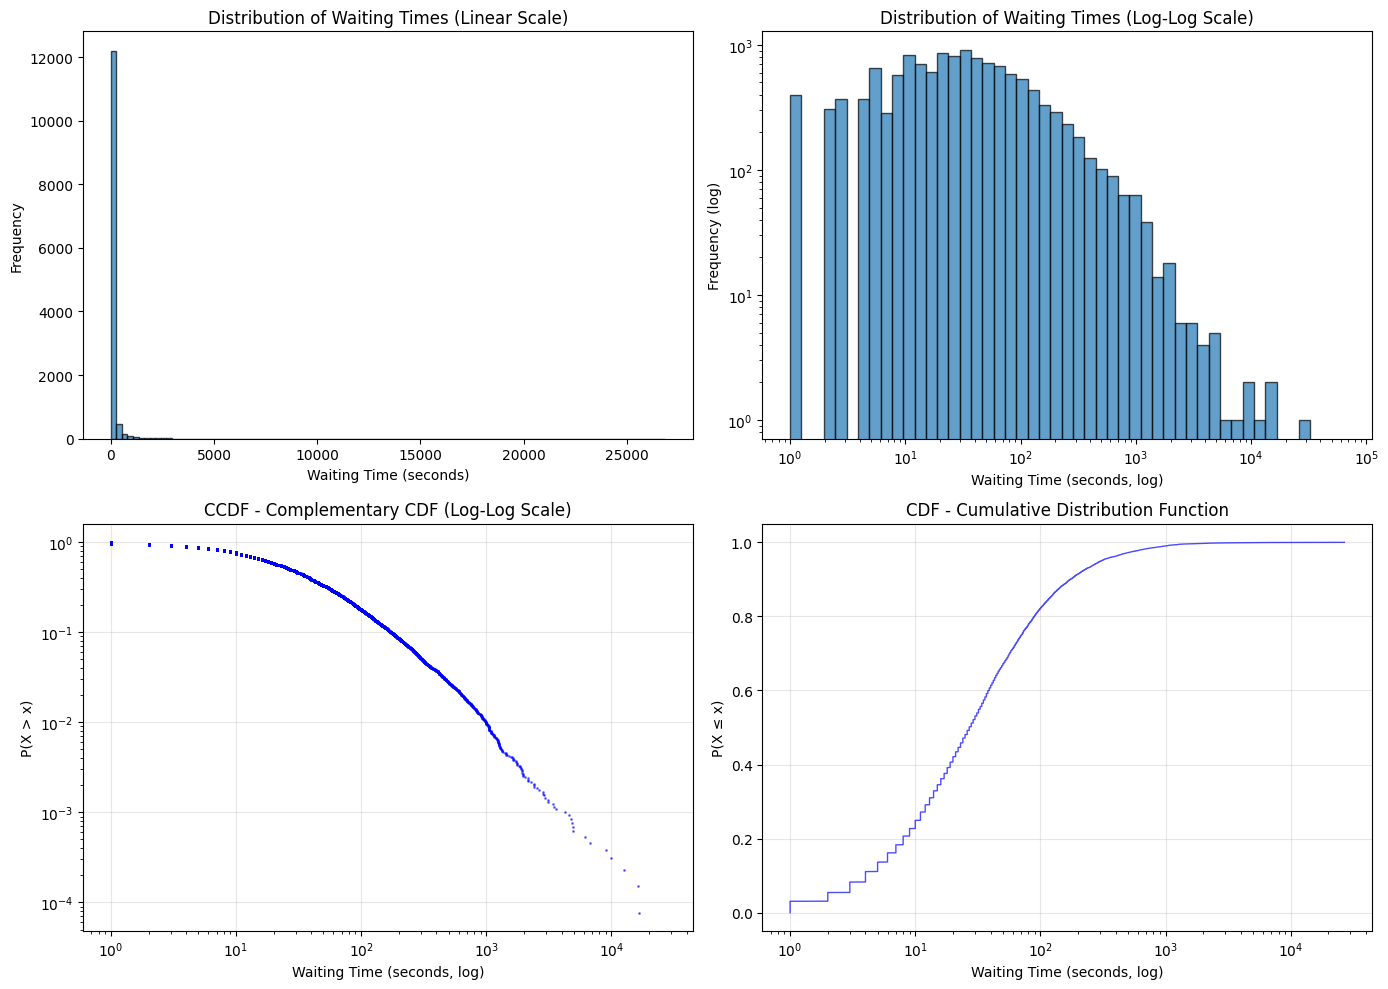

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram on linear scale
axes[0, 0].hist(waiting_times_w, bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Waiting Time (seconds)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Waiting Times (Linear Scale)')

# Histogram on log-log scale
axes[0, 1].hist(waiting_times_w, bins=np.logspace(np.log10(waiting_times.min()), 
                                                  np.log10(waiting_times.max()), 50),
                edgecolor='black', alpha=0.7)
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')
axes[0, 1].set_xlabel('Waiting Time (seconds, log)')
axes[0, 1].set_ylabel('Frequency (log)')
axes[0, 1].set_title('Distribution of Waiting Times (Log-Log Scale)')

# CCDF (Complementary Cumulative Distribution Function) on log-log scale
sorted_times_w = np.sort(waiting_times_w)
ccdf = 1 - np.arange(1, len(sorted_times_w) + 1) / len(sorted_times_w)
axes[1, 0].plot(sorted_times_w, ccdf, 'b.', alpha=0.5, markersize=2)
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
axes[1, 0].set_xlabel('Waiting Time (seconds, log)')
axes[1, 0].set_ylabel('P(X > x)')
axes[1, 0].set_title('CCDF - Complementary CDF (Log-Log Scale)')
axes[1, 0].grid(True, alpha=0.3)

# CDF
axes[1, 1].plot(sorted_times_w, np.arange(1, len(sorted_times_w) + 1) / len(sorted_times_w), 
                'b-', alpha=0.7, linewidth=1)
axes[1, 1].set_xscale('log')
axes[1, 1].set_xlabel('Waiting Time (seconds, log)')
axes[1, 1].set_ylabel('P(X ≤ x)')
axes[1, 1].set_title('CDF - Cumulative Distribution Function')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Truncated power law fit

TRUNCATED POWER LAW FIT RESULTS
alpha: 2.0037
lambda: 0.000176
xmin: 78.0000
sigma: nan
Data points above xmin: 2991 / 12983 (23.04%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 2.4539, p = 0.0000
  ✓ Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = -1.9831, p = 0.0474
  ✗ lognormal is significantly better

Truncated PL vs Exponential:
  R = 6.4133, p = 0.0000
  ✓ Truncated power law is significantly better


Assuming nested distributions



KS distance (truncated power law): 0.0192
✓ Good fit (KS < 0.1)


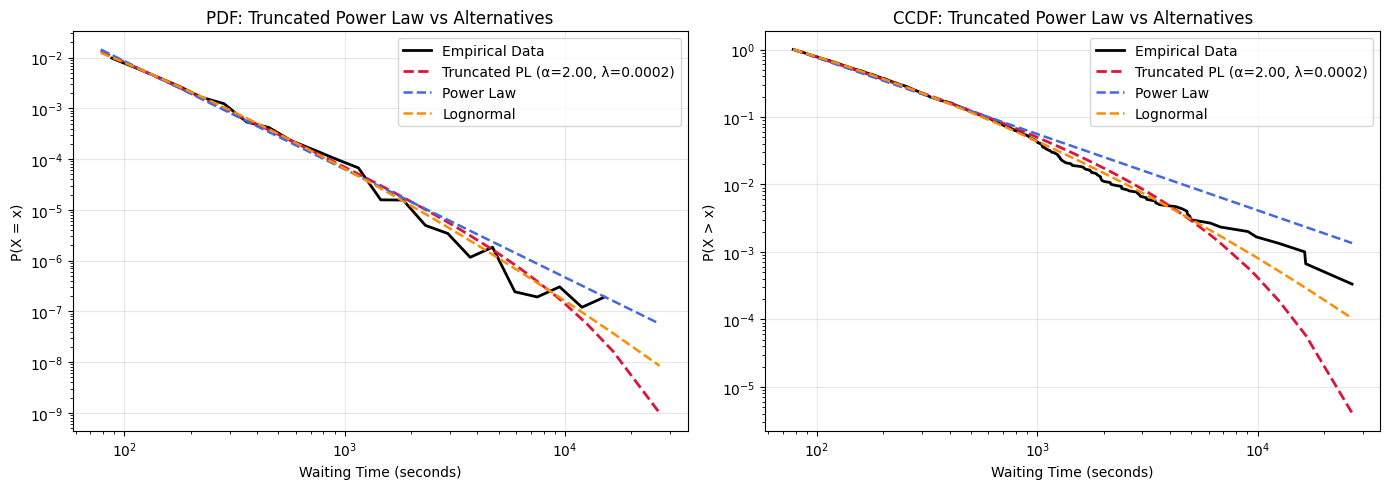

KS statistic (tail): 0.019513
KS p-value (tail): 0.202158


In [14]:
import powerlaw

# Prepare data
data_tpl_w = np.asarray(waiting_times_w.values, dtype=float)
data_tpl_w = data_tpl_w[np.isfinite(data_tpl_w)]
data_tpl_w = data_tpl_w[data_tpl_w > 0]

# Fit using powerlaw package
fit_tpl_w = powerlaw.Fit(data_tpl_w, discrete=False, verbose=False)
tpl_w = fit_tpl_w.truncated_power_law

alpha_tpl_w = getattr(tpl_w, "alpha", np.nan)
lambda_tpl_w = getattr(tpl_w, "Lambda", np.nan)
xmin_tpl_w = getattr(tpl_w, "xmin", np.nan)
sigma_tpl_w = getattr(tpl_w, "sigma", np.nan)

print("="*70)
print("TRUNCATED POWER LAW FIT RESULTS")
print("="*70)
print(f"alpha: {alpha_tpl_w:.4f}")
print(f"lambda: {lambda_tpl_w:.6f}")
print(f"xmin: {xmin_tpl_w:.4f}")
print(f"sigma: {sigma_tpl_w:.4f}")
n_tail_tpl_w = int(np.sum(data_tpl_w >= xmin_tpl_w))
print(f"Data points above xmin: {n_tail_tpl_w} / {len(data_tpl_w)} ({100 * n_tail_tpl_w / len(data_tpl_w):.2f}%)")

# Likelihood-ratio comparisons (positive R => first model preferred)
print("\n" + "="*70)
print("TRUNCATED POWER LAW COMPARISONS")
print("="*70)
comparisons = [
    ("truncated_power_law", "power_law", "Truncated PL vs Power Law"),
    ("truncated_power_law", "lognormal", "Truncated PL vs Lognormal"),
    ("truncated_power_law", "exponential", "Truncated PL vs Exponential"),
]

for d1, d2, label in comparisons:
    R, p = fit_tpl_w.distribution_compare(d1, d2, normalized_ratio=True)
    print(f"\n{label}:")
    print(f"  R = {R:.4f}, p = {p:.4f}")
    if p < 0.05:
        if R > 0:
            print("  ✓ Truncated power law is significantly better")
        else:
            print(f"  ✗ {d2.replace('_', ' ')} is significantly better")
    else:
        print("  ≈ No significant difference")

# Manual KS distance for truncated power law
tail_tpl_w = np.sort(data_tpl_w[data_tpl_w >= xmin_tpl_w])
if len(tail_tpl_w) == 0:
    ks_tpl_w = float("nan")
else:
    empirical_cdf_tpl_w = np.arange(1, len(tail_tpl_w) + 1) / len(tail_tpl_w)
    try:
        model_cdf_tpl_w = tpl_w.cdf(tail_tpl_w)
    except Exception:
        model_cdf_tpl_w = 1 - tpl_w.ccdf(tail_tpl_w)
    ks_tpl_w = np.max(np.abs(empirical_cdf_tpl_w - model_cdf_tpl_w))

print("\n" + "="*70)
print(f"KS distance (truncated power law): {ks_tpl_w:.4f}")
if np.isnan(ks_tpl_w):
    print("KS could not be computed (no data >= xmin).")
elif ks_tpl_w < 0.1:
    print("✓ Good fit (KS < 0.1)")
elif ks_tpl_w < 0.15:
    print("~ Moderate fit (0.1 ≤ KS < 0.15)")
else:
    print("✗ Poor fit (KS ≥ 0.15)")
print("="*70)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fit_tpl_w.plot_pdf(color='black', linewidth=2, label='Empirical Data', ax=axes[0])
tpl_w.plot_pdf(
    color='crimson', linestyle='--', linewidth=2,
    label=f'Truncated PL (α={alpha_tpl_w:.2f}, λ={lambda_tpl_w:.4f})', ax=axes[0]
 )
fit_tpl_w.power_law.plot_pdf(color='royalblue', linestyle='--', linewidth=1.8, label='Power Law', ax=axes[0])
fit_tpl_w.lognormal.plot_pdf(color='darkorange', linestyle='--', linewidth=1.8, label='Lognormal', ax=axes[0])
axes[0].set_xlabel('Waiting Time (seconds)')
axes[0].set_ylabel('P(X = x)')
axes[0].set_title('PDF: Truncated Power Law vs Alternatives')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

fit_tpl_w.plot_ccdf(color='black', linewidth=2, label='Empirical Data', ax=axes[1])
tpl_w.plot_ccdf(
    color='crimson', linestyle='--', linewidth=2,
    label=f'Truncated PL (α={alpha_tpl_w:.2f}, λ={lambda_tpl_w:.4f})', ax=axes[1]
 )
fit_tpl_w.power_law.plot_ccdf(color='royalblue', linestyle='--', linewidth=1.8, label='Power Law', ax=axes[1])
fit_tpl_w.lognormal.plot_ccdf(color='darkorange', linestyle='--', linewidth=1.8, label='Lognormal', ax=axes[1])
axes[1].set_xlabel('Waiting Time (seconds)')
axes[1].set_ylabel('P(X > x)')
axes[1].set_title('CCDF: Truncated Power Law vs Alternatives')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# One-off: compute KS p-value for truncated power law tail fit
from scipy import stats

tail_tpl_w = np.sort(data_tpl_w[data_tpl_w >= xmin_tpl_w])
ks_stat_tpl_w, ks_p_tpl_w = stats.kstest(tail_tpl_w, tpl_w.cdf)
print("="*70)
print(f"KS statistic (tail): {ks_stat_tpl_w:.6f}")
print(f"KS p-value (tail): {ks_p_tpl_w:.6g}")
print("="*70)

### Normal power law

In [15]:
# Fit to a power law (without truncation) for comparison
fit_pl_w = powerlaw.Fit(data_tpl_w, discrete=False, verbose=False)
alpha_pl_w = getattr(fit_pl_w.power_law, "alpha", np.nan)
xmin_pl_w = getattr(fit_pl_w.power_law, "xmin", np.nan)
print("="*70)
print("POWER LAW FIT RESULTS")
print("="*70)
print(f"alpha: {alpha_pl_w:.4f}")
print(f"xmin: {xmin_pl_w:.4f}")
n_tail_pl_w = int(np.sum(data_tpl_w >= xmin_pl_w))
print(f"Data points above xmin: {n_tail_pl_w} / {len(data_tpl_w)} ({100 * n_tail_pl_w / len(data_tpl_w):.2f}%)")


POWER LAW FIT RESULTS
alpha: 2.1306
xmin: 78.0000
Data points above xmin: 2991 / 12983 (23.04%)


In [16]:
# KS test for power law fit
tail_pl_w = np.sort(data_tpl_w[data_tpl_w >= xmin_pl_w])
ks_stat_pl_w, ks_p_pl_w = stats.kstest(tail_pl_w, fit_pl_w.power_law.cdf)
print("\n" + "="*70)
print(f"KS statistic (power law tail): {ks_stat_pl_w:.6f}")
print(f"KS p-value (power law tail): {ks_p_pl_w:.6g}")
print("="*70)



KS statistic (power law tail): 0.036946
KS p-value (power law tail): 0.00055368


### log-normal distribution

In [17]:
# Fit to lognormal for comparison
fit_ln_w = powerlaw.Fit(data_tpl_w, discrete=False, verbose=False)
alpha_ln_w = getattr(fit_ln_w.lognormal, "mu", np.nan)
sigma_ln_w = getattr(fit_ln_w.lognormal, "sigma", np.nan)
print("\n" + "="*70)
print("LOGNORMAL FIT RESULTS")
print("="*70)
print(f"mu: {alpha_ln_w:.4f}")
print(f"sigma: {sigma_ln_w:.4f}")
print(f"Data points above lognormal xmin: {len(data_tpl_w)} / {len(data_tpl_w)} (100.00%)")
print("="*70)

# KS test for lognormal fit
tail_ln_w = np.sort(data_tpl_w)
ks_stat_ln_w, ks_p_ln_w = stats.kstest(tail_ln_w, fit_ln_w.lognormal.cdf)
print("\n" + "="*70)
print(f"KS statistic (lognormal): {ks_stat_ln_w:.6f}")
print(f"KS p-value (lognormal): {ks_p_ln_w:.6g}")
print("="*70)

xmin progress: 99%
LOGNORMAL FIT RESULTS
mu: 0.9123
sigma: 2.1087
Data points above lognormal xmin: 12983 / 12983 (100.00%)

KS statistic (lognormal): 0.014769
KS p-value (lognormal): 0.00686801
